In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unrar x -Y "/content/MrZoz.rar"


UNRAR 5.50 freeware      Copyright (c) 1993-2017 Alexander Roshal

Cannot open /content/MrZoz.rar
No such file or directory
No files to extract


In [2]:
import tensorflow.keras
from tensorflow.keras import layers
from tensorflow.keras import backend as K
from tensorflow.keras.layers import Dense, Activation ,Dropout, BatchNormalization , Rescaling
#from tensorflow.keras.optimizers import Adam # - Works
#from tensorflow.keras.metrics import categorical_crossentropy
#from tensorflow.keras.preprocessing.image import ImageDataGenerator
#from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model ,load_model
from tensorflow.keras.applications import imagenet_utils
from tensorflow.keras.layers import Dense,GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications.mobilenet import MobileNet
from tensorflow.keras.applications.mobilenet import preprocess_input
import tensorflow as tf
import numpy as np
from IPython.display import Image
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import ModelCheckpoint
from keras.utils.vis_utils import plot_model

In [3]:
mobile = tensorflow.keras.applications.mobilenet.MobileNet()

17235968/17225924 [==============================] - 0s 0us/step


In [4]:
mobile.summary()
len(mobile.layers)

Model: "mobilenet_1.00_224"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 conv1 (Conv2D)              (None, 112, 112, 32)      864       
                                                                 
 conv1_bn (BatchNormalizatio  (None, 112, 112, 32)     128       
 n)                                                              
                                                                 
 conv1_relu (ReLU)           (None, 112, 112, 32)      0         
                                                                 
 conv_dw_1 (DepthwiseConv2D)  (None, 112, 112, 32)     288       
                                                                 
 conv_dw_1_bn (BatchNormaliz  (None, 112, 112, 32)     128       
 ation)                                         

91

In [5]:
def preprocess(images, labels):
  return tf.keras.applications.mobilenet.preprocess_input(images), labels

In [6]:
train_ds = tf.keras.utils.image_dataset_from_directory(
  "/content/drive/MyDrive/Train2",
  image_size=(224, 224),
  batch_size=16,
  )
val_ds = tf.keras.utils.image_dataset_from_directory(
  "/content/drive/MyDrive/Validation2",
  image_size=(224, 224),
  batch_size=16)


train_ds = train_ds.map(preprocess)
val_ds = val_ds.map(preprocess)


Found 160 files belonging to 2 classes.
Found 40 files belonging to 2 classes.


In [7]:
from tensorflow import keras

data_augmentation = keras.Sequential([
    layers.experimental.preprocessing.RandomFlip("horizontal"),
    layers.experimental.preprocessing.RandomRotation(0.1),
    layers.experimental.preprocessing.RandomZoom(0.1),
  ])


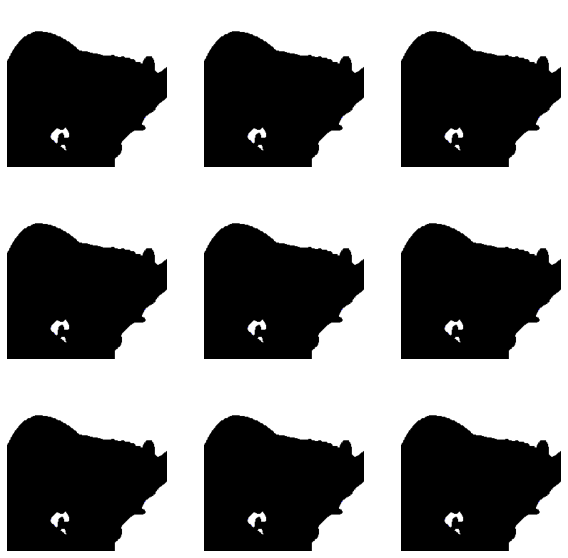

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[1].numpy().astype("uint8"))
    plt.axis("off")

In [16]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [17]:
normalization_layer = layers.Rescaling(1./255)

In [18]:
import numpy as np 
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixel values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image)) 

-0.003921569 0.0036145274


In [19]:
base_model = MobileNet(weights = 'imagenet', include_top = False) #imports the mobilenet model and discards the last 1000 neuron layer.

base_model.trainable = False

x = base_model.output
x = data_augmentation(x)
x = Rescaling(1./255)(x)
x = GlobalAveragePooling2D()(x)
x = Dense(64,activation='relu')(x) #we add dense layers so that the model can learn more complex functions and classify for better results.
x = BatchNormalization()(x)
x = Dropout(rate=0.6)(x)
x = Dense(32,activation='relu')(x) #dense layer 2
x = Dense(16,activation='relu')(x) #dense layer 3

preds = Dense(1, activation='sigmoid')(x) #final layer with softmax activation

17235968/17225924 [==============================] - 0s 0us/step


In [20]:
model = Model(inputs=base_model.input,outputs=preds)

In [21]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, None, None, 3)]   0         
                                                                 
 conv1 (Conv2D)              (None, None, None, 32)    864       
                                                                 
 conv1_bn (BatchNormalizatio  (None, None, None, 32)   128       
 n)                                                              
                                                                 
 conv1_relu (ReLU)           (None, None, None, 32)    0         
                                                                 
 conv_dw_1 (DepthwiseConv2D)  (None, None, None, 32)   288       
                                                                 
 conv_dw_1_bn (BatchNormaliz  (None, None, None, 32)   128       
 ation)                                                      

In [22]:
len(model.layers)

95



In [23]:
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

In [24]:
opt = tf.optimizers.Adam(learning_rate=0.001)

In [25]:
model.compile(optimizer=opt , loss = 'binary_crossentropy' ,metrics=['acc'])

# Adam optimizer
# loss function will be categorical cross entropy
# evaluation metric will be accuracy

#step_size_train = train_generator.n // train_generator.batch_size

checkpointer = ModelCheckpoint(filepath ='mobilenet_V1_best',
                             monitor = 'val_acc',
                             verbose = 1,
                             save_best_only = True)

# class CustomCallback(tf.keras.callbacks.Callback):
#     def on_epoch_end(self, epoch, logs=None):
#         keys = list(logs.keys())
#         if(float(logs.get('val_acc')) > 0.92):
#             self.model.stop_training = True

# callbacks = tf.keras.callbacks.EarlyStopping(monitor='val_acc', patience=20)

history = model.fit_generator(generator = train_ds,
        validation_data = val_ds,
       epochs = 300 , shuffle = True , callbacks=[checkpointer])

Epoch 1/300


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:24: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.


10/10 [==============================] - ETA: 0s - loss: 0.7038 - acc: 0.4250
Epoch 1: val_acc improved from -inf to 0.50000, saving model to mobilenet_V1_best
INFO:tensorflow:Assets written to: mobilenet_V1_best/assets
10/10 [==============================] - 35s 2s/step - loss: 0.7038 - acc: 0.4250 - val_loss: 0.6932 - val_acc: 0.5000
Epoch 2/300
 9/10 [==========================>...] - ETA: 0s - loss: 0.6744 - acc: 0.7083
Epoch 2: val_acc did not improve from 0.50000
10/10 [==============================] - 1s 59ms/step - loss: 0.6777 - acc: 0.6875 - val_loss: 0.6932 - val_acc: 0.5000
Epoch 3/300
 9/10 [==========================>...] - ETA: 0s - loss: 0.6577 - acc: 0.7222
Epoch 3: val_acc did not improve from 0.50000
10/10 [==============================] - 1s 57ms/step - loss: 0.6622 - acc: 0.6938 - val_loss: 0.6939 - val_acc: 0.5000
Epoch 4/300
 9/10 [==========================>...] - ETA: 0s - loss: 0.6250 - acc: 0.8056
Epoch 4: val_acc did not improve from 0.50000
10/10 [======

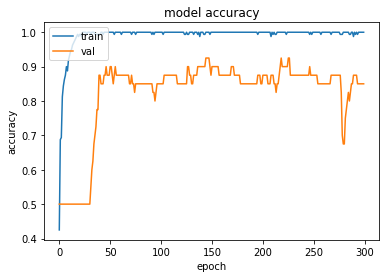

In [26]:
from matplotlib import pyplot as plt
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.savefig('model_accuracy_moblienets.png')
plt.show()


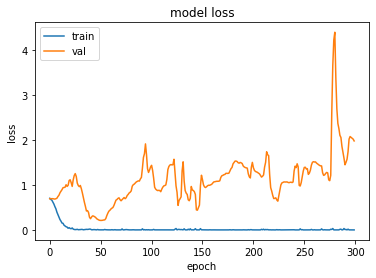

In [27]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.savefig('model_loss_moblienets.png')
plt.show()


In [28]:
model.evaluate(val_ds)

3/3 [==============================] - 0s 35ms/step - loss: 1.9791 - acc: 0.8500


[1.9790763854980469, 0.8500000238418579]